In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/after_feature_construction (2).csv")

In [ ]:
df.shape

(10025, 54)

In [ ]:
df.columns
train_df = df.drop(columns=['salary_growth_potential','salary_per_skill','remote_premium_salary',
'Salary_Distribution','industry_salary', 'country_salary','salary_percentile', 'salary_zscore','industry_salary_rank','salary_gap'])

<Axes: >

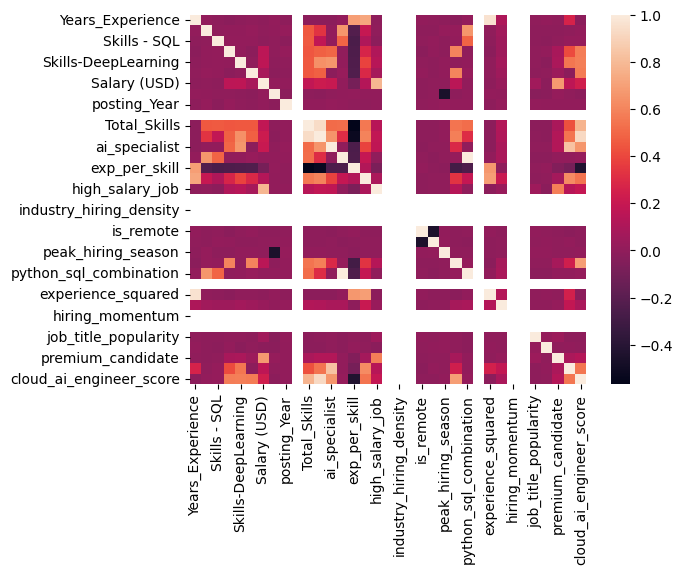

In [ ]:
sns.heatmap(train_df.corr(numeric_only=True))

In [ ]:
train_df.corr(numeric_only=True)['Salary (USD)'].sort_values(ascending=False)

,Salary (USD)
Salary (USD),1.000000
high_salary_job,0.781943
premium_candidate,0.669806
cloud_ai_engineer_score,0.234766
advanced_skill_score,0.218836
ai_specialist,0.198381
Total_Skills,0.175721
Skills-DeepLearning,0.164815
ai_seniority_score,0.164646
Skills - ML,0.157282


In [ ]:
df = df.drop(columns=['salary_growth_potential','salary_per_skill','remote_premium_salary',
'Salary_Distribution','industry_salary', 'country_salary','salary_percentile', 'salary_zscore','industry_salary_rank',
'salary_gap','is_remote', 'is_hybrid','hiring_quarter', 'peak_hiring_season','industry_hiring_density',
'experience_squared', 'skill_intersection_power', 'hiring_momentum','market_expansion_score','high_salary_job','ai_seniority_score',
       'cloud_ai_engineer_score'])

In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings', 'Total_Skills',
       'advanced_skill_score', 'ai_specialist', 'data_professional',
       'exp_per_skill', 'experience_intensity', 'skill_demand_score',
       'country_demand_score', 'ml_cloud_combination',
       'python_sql_combination', 'competition_ratio', 'job_title_popularity',
       'industry_frequency', 'premium_candidate'],
      dtype='object')

In [ ]:
df.shape

(10025, 32)

### Label Encoding Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = [
    'JobTitle',
    'Company Size',
    'company_Industry',
    'Country',
    'Remote Type',
    'Exp. Level',
    'Education  Level',
    'Hiring Urgency'
]

# Create a copy of the DataFrame to store encoded values
df_encoded = df.copy()

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])
        print(f"Column '{col}' encoded successfully.")
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

# Display the head of the encoded DataFrame to verify
display(df_encoded.head())

Column 'JobTitle' encoded successfully.
Column 'Company Size' encoded successfully.
Column 'company_Industry' encoded successfully.
Column 'Country' encoded successfully.
Column 'Remote Type' encoded successfully.
Column 'Exp. Level' encoded successfully.
Column 'Education  Level' encoded successfully.
Column 'Hiring Urgency' encoded successfully.


,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,...,exp_per_skill,experience_intensity,skill_demand_score,country_demand_score,ml_cloud_combination,python_sql_combination,competition_ratio,job_title_popularity,industry_frequency,premium_candidate
0,2,2,2,7,0,1,4.0,0,1,1,...,2.000000,12.0,0.0,0.0,0,1,0.0,1626,1595,0
1,4,0,0,5,0,3,8.0,0,1,0,...,2.000000,96.0,0.0,0.0,1,0,0.0,1661,1567,0
2,2,2,5,4,0,2,8.0,1,1,1,...,1.600000,104.0,0.0,0.0,1,1,0.0,1626,1494,0
3,4,0,1,1,3,1,7.0,0,1,1,...,2.333333,49.0,0.0,0.0,0,1,0.0,1661,1531,0
4,5,1,4,2,0,2,10.0,2,0,1,...,3.333333,70.0,0.0,0.0,1,0,0.0,1682,1611,0


### Defining X and y from the Encoded Dataset

In [ ]:
# Define X and y from the encoded DataFrame
X = df_encoded.drop(columns=['Salary (USD)'])
y = df_encoded['Salary (USD)']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

display(X.head())
display(y.head())

Shape of X: (10025, 31)
Shape of y: (10025,)


,JobTitle,Company Size,company_Industry,Country,Remote Type,Exp. Level,Years_Experience,Education Level,Skills - Python,Skills - SQL,...,exp_per_skill,experience_intensity,skill_demand_score,country_demand_score,ml_cloud_combination,python_sql_combination,competition_ratio,job_title_popularity,industry_frequency,premium_candidate
0,2,2,2,7,0,1,4.0,0,1,1,...,2.000000,12.0,0.0,0.0,0,1,0.0,1626,1595,0
1,4,0,0,5,0,3,8.0,0,1,0,...,2.000000,96.0,0.0,0.0,1,0,0.0,1661,1567,0
2,2,2,5,4,0,2,8.0,1,1,1,...,1.600000,104.0,0.0,0.0,1,1,0.0,1626,1494,0
3,4,0,1,1,3,1,7.0,0,1,1,...,2.333333,49.0,0.0,0.0,0,1,0.0,1661,1531,0
4,5,1,4,2,0,2,10.0,2,0,1,...,3.333333,70.0,0.0,0.0,1,0,0.0,1682,1611,0


,Salary (USD)
0,61640.0
1,138483.0
2,119038.0
3,66667.0
4,153801.0


**Random forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Create masks for finite values in X and non-NaN values in y
# This step first converts any inf/-inf to NaN, then checks for all non-NaN values
finite_X_mask = X.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
notna_y_mask = y.notna()

# Combine masks to ensure both X and y are clean for the corresponding rows
combined_mask = finite_X_mask & notna_y_mask

# Apply masks to filter X and y
X_filtered = X[combined_mask].copy()
y_filtered = y[combined_mask].copy()

print(f"Original X shape: {X.shape}, Filtered X shape: {X_filtered.shape}")
print(f"Original y shape: {y.shape}, Filtered y shape: {y_filtered.shape}")

# Train a Random Forest regressor on the filtered data
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_filtered, y_filtered)

# Extract feature importance scores for label encoded data, using filtered X's columns
fi_df1 = pd.DataFrame({
    'feature': X_filtered.columns,
    'rf_importance': rf.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df1

Original X shape: (10025, 31), Filtered X shape: (9771, 31)
Original y shape: (10025,), Filtered y shape: (9771,)


,feature,rf_importance
30,premium_candidate,0.449793
5,Exp. Level,0.177837
28,job_title_popularity,0.132217
18,advanced_skill_score,0.039639
1,Company Size,0.019063
13,Posting Month,0.017425
22,experience_intensity,0.017416
0,JobTitle,0.016533
21,exp_per_skill,0.014980
3,Country,0.014728


**Gradient Boosting**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_filtered, y_filtered)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df2

,feature,gb_importance
30,premium_candidate,0.549221
5,Exp. Level,0.203650
0,JobTitle,0.133135
28,job_title_popularity,0.054769
18,advanced_skill_score,0.024152
1,Company Size,0.011604
19,ai_specialist,0.010381
10,Skills - ML,0.004739
11,Skills-DeepLearning,0.001959
25,ml_cloud_combination,0.001663


**Lasso**

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_filtered)

# Extract coefficients
fi_df3 = pd.DataFrame({
    'feature': X.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df3

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.435e+11, tolerance: 1.149e+09
  model = cd_fast.enet_coordinate_descent(


,feature,lasso_coeff
30,premium_candidate,20158.927400
5,Exp. Level,10334.524486
10,Skills - ML,3714.755741
11,Skills-DeepLearning,3646.999282
12,skills_Cloud,1965.398374
22,experience_intensity,1299.098684
21,exp_per_skill,1148.959650
28,job_title_popularity,1085.670497
13,Posting Month,370.466520
0,JobTitle,295.073064


**SHAP**

In [ ]:
!pip install shap

In [ ]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_filtered, y_filtered)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_filtered)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

In [ ]:
fi_df4 = pd.DataFrame({
    'feature': X.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df4

In [ ]:
final_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature')

In [ ]:
numeric_cols = ['rf_importance', 'gb_importance', 'lasso_coeff']
final_df[numeric_cols] = final_df[numeric_cols].divide(final_df[numeric_cols].sum(axis=0), axis=1)

In [ ]:
final_df.sort_values(ascending=False, by=['rf_importance','gb_importance'])

,feature,rf_importance,gb_importance,lasso_coeff
0,premium_candidate,0.449793,0.549221,0.516206
1,Exp. Level,0.177837,0.203650,0.264634
2,job_title_popularity,0.132217,0.054769,0.027801
3,advanced_skill_score,0.039639,0.024152,-0.000481
4,Company Size,0.019063,0.011604,-0.057438
5,Posting Month,0.017425,0.000234,0.009486
6,experience_intensity,0.017416,0.000386,0.033266
7,JobTitle,0.016533,0.133135,0.007556
8,exp_per_skill,0.014980,0.000679,0.029421
9,Country,0.014728,0.000216,-0.009312


In [ ]:
df.columns

Index(['JobTitle', 'Company Size', 'company_Industry', 'Country',
       'Remote Type', 'Exp. Level', 'Years_Experience', 'Education  Level',
       'Skills - Python', 'Skills - SQL', 'Skills - ML', 'Skills-DeepLearning',
       'skills_Cloud', 'Salary (USD)', 'Posting Month', 'posting_Year',
       'Hiring Urgency', 'Job Openings', 'Total_Skills',
       'advanced_skill_score', 'ai_specialist', 'data_professional',
       'exp_per_skill', 'experience_intensity', 'skill_demand_score',
       'country_demand_score', 'ml_cloud_combination',
       'python_sql_combination', 'competition_ratio', 'job_title_popularity',
       'industry_frequency', 'premium_candidate'],
      dtype='object')

In [ ]:
cols = ['python_sql_combination','data_professional','country_demand_score','skill_demand_score','competition_ratio','Job Openings']

In [ ]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_filtered, y_filtered, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8009728915201799)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_filtered.drop(columns=cols), y_filtered, cv=5, scoring='r2')

In [ ]:
scores.mean()

np.float64(0.8012407395147043)

In [ ]:
export_df = X_filtered.drop(columns=cols)
export_df['Salary (USD)'] = y_filtered

In [ ]:
export_df.to_csv("after_feature_selection.csv", index=False)